### *CELL 1 — Markdown (short, thesis-ready)*

# Notebook 08 — Multi-Threshold Flood Risk Diagnostics (2001–2021)

## 1. Purpose

This notebook provides a comprehensive flood-risk assessment of Lake Victoria water levels at Jinja under three operational scenarios:

- **Observed Operations** (measured lake levels)
- **Baseline Policy (Agreed Curve Simulation)**
- **Optimized Rule Curve Policy (Best-Compromise Solution)**

The objective is to quantify how different regulation policies influence flood frequency, flood severity, and event persistence over the 2001–2021 analysis period.

This notebook translates visual comparisons from Notebook 07 into statistically defensible flood metrics suitable for thesis reporting and policy evaluation.

---

## 2. Multi-Threshold Framework

Flood risk is evaluated at three high-water thresholds:

- **12.5 m** → Moderate flood regime  
- **12.8 m** → High flood reference threshold  
- **13.0 m** → Extreme flood regime  

Using multiple thresholds ensures robustness of policy performance across different flood intensity regimes and avoids conclusions that depend on a single cutoff.

---

## 3. Metrics Computed

For each scenario and threshold, the following diagnostics are calculated:

### A. Frequency Metrics
- Total days above threshold
- Annual flood days
- Number of discrete flood events

### B. Duration Metrics
- Maximum event duration (longest consecutive exceedance streak)
- Mean event duration

### C. Severity Metrics
- Peak level during exceedance events
- Total exceedance severity (m-days)
  - Defined as the sum of (lake level − threshold) across all exceedance days
  - Represents integrated flood magnitude

These metrics together capture:

- **How often flooding occurs**
- **How long it persists**
- **How intense it becomes**
- **How much total flood energy accumulates**

---

## 4. Hydrological Interpretation Strategy

Flood risk is not defined solely by peak level. It is a compound outcome of:

- Frequency of exceedance
- Duration of sustained high levels
- Integrated severity above critical thresholds

By comparing these metrics across Observed, Baseline, and Optimized policies, this notebook evaluates whether the optimized rule curve:

- Reduces high-water exceedance frequency
- Limits extreme peaks
- Shortens prolonged flood episodes
- Maintains system stability without excessive drawdown

---

## 5. Expected Analytical Outcomes

Based on prior notebooks:

- The **Baseline (Agreed Curve)** is expected to show minimal exceedance but excessive long-term drawdown.
- The **Observed regime** is expected to show elevated exceedance frequency and severity during extreme years.
- The **Optimized policy** should demonstrate moderated exceedance and improved severity shaping without violating system constraints.

---

## 6. Deliverables Produced

This notebook exports:

- Multi-threshold flood metrics table (CSV)
- Annual flood-day time series (CSV)
- Bar charts comparing exceedance days
- Bar charts comparing total severity
- Annual flood evolution plots
- Thesis-ready interpretative paragraph

These outputs form the quantitative foundation for the final policy evaluation chapter.

---

**Notebook Position in Project Pipeline:**

01–05 → Hydrological reconstruction and balance  
06 → Policy optimization  
07 → Scenario evaluation  
08 → Flood diagnostics and extreme-event characterization  

This notebook completes the flood-risk quantification stage of the study.

### *CELL 2 — Imports + Paths*

In [1]:
from __future__ import annotations

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


PROJECT_DIR = Path.cwd().parents[0]
DATA_RAW = PROJECT_DIR / "data" / "raw"
DATA_PROCESSED = PROJECT_DIR / "data" / "processed"
OUTPUT_DIR = PROJECT_DIR / "outputs"
TAB_DIR = PROJECT_DIR / "outputs" / "tables"
FIG_DIR = PROJECT_DIR / "outputs" / "figures"

TAB_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)


print("PROJECT_DIR:", PROJECT_DIR.resolve())
print("DATA_PROCESSED:", DATA_PROCESSED.resolve())
print("DATA_RAW:", DATA_RAW.resolve())
print("OUTPUT_DIR:", OUTPUT_DIR.resolve())

PROJECT_DIR: C:\Users\Nelson\Downloads\LakeVictoria_Optimization
DATA_PROCESSED: C:\Users\Nelson\Downloads\LakeVictoria_Optimization\data\processed
DATA_RAW: C:\Users\Nelson\Downloads\LakeVictoria_Optimization\data\raw
OUTPUT_DIR: C:\Users\Nelson\Downloads\LakeVictoria_Optimization\outputs


### *CELL 3 — Load the 06 simulations (baseline + optimized) and extract observed*

In [2]:
baseline_path  = DATA_PROCESSED / "06_baseline_agreedcurve_sim.csv"
optimized_path = DATA_PROCESSED / "06_optimized_rulecurve_sim.csv"

baseline_df  = pd.read_csv(baseline_path, parse_dates=["date"]).set_index("date")
optimized_df = pd.read_csv(optimized_path, parse_dates=["date"]).set_index("date")

# Observed levels aligned on the same daily index (carried inside sim output)
# (This is consistent with your earlier findings: level_obs_m exists in both)
observed_ser = baseline_df["level_obs_m"].astype(float)

baseline_ser = baseline_df["level_sim_m"].astype(float)
optimized_ser = optimized_df["level_sim_m"].astype(float)

print("Loaded:", baseline_path.name, optimized_path.name)
print("Index range:", baseline_df.index.min(), "->", baseline_df.index.max())
print("Columns baseline:", baseline_df.columns.tolist())

Loaded: 06_baseline_agreedcurve_sim.csv 06_optimized_rulecurve_sim.csv
Index range: 2001-01-01 00:00:00 -> 2021-04-27 00:00:00
Columns baseline: ['stage_rel_m', 'storage_true_m3', 'area_m2', 'level_sim_m', 'level_obs_m', 'vol_p_minus_e_m3d', 'vol_qin_m3d', 'vol_qout_m3d', 'vol_gw_m3d', 'dS_m3d', 'qin_scaled_m3s', 'qout_policy_m3s']


### *CELL 4 — Define thresholds + core flood metric functions*

In [3]:
THRESHOLDS_M = [12.5, 12.8, 13.0]

def compute_exceedance_events(level: pd.Series, thr: float) -> pd.DataFrame:
    """
    Return event table for exceedances above thr.
    Each event: start, end, duration_days, peak_level, severity_m_days
    severity_m_days = sum(level - thr) over event days (m-days).
    """
    s = level.dropna().astype(float).copy()
    exceed = s > thr
    
    # Identify contiguous True blocks
    grp = (exceed != exceed.shift(1)).cumsum()
    events = []
    for g, mask in exceed.groupby(grp):
        if not bool(mask.iloc[0]):
            continue
        idx = mask.index
        start, end = idx[0], idx[-1]
        duration = (end - start).days + 1
        seg = s.loc[start:end]
        peak = float(seg.max())
        severity = float((seg - thr).clip(lower=0).sum())  # m-days
        events.append((start, end, duration, peak, severity))
        
    return pd.DataFrame(
        events,
        columns=["start", "end", "duration_days", "peak_level_m", "severity_m_days"]
    )

def summarize_flood_metrics(level: pd.Series, thr: float, scenario: str) -> dict:
    s = level.dropna().astype(float)
    exceed = s > thr
    
    ev = compute_exceedance_events(s, thr)
    out = {
        "scenario": scenario,
        "threshold_m": float(thr),
        "days_above_threshold": int(exceed.sum()),
        "max_level_m": float(s.max()),
        "mean_level_m": float(s.mean()),
        "event_count": int(len(ev)),
        "max_event_duration_days": int(ev["duration_days"].max()) if len(ev) else 0,
        "total_severity_m_days": float(ev["severity_m_days"].sum()) if len(ev) else 0.0,
        "mean_event_duration_days": float(ev["duration_days"].mean()) if len(ev) else 0.0,
        "mean_event_peak_m": float(ev["peak_level_m"].mean()) if len(ev) else 0.0,
    }
    return out

### *CELL 5 — Build the main multi-threshold flood metrics table*

In [4]:
scenarios = {
    "Observed": observed_ser,
    "Baseline (Agreed Curve)": baseline_ser,
    "Optimized Rule": optimized_ser,
}

rows = []
for thr in THRESHOLDS_M:
    for name, ser in scenarios.items():
        rows.append(summarize_flood_metrics(ser, thr, name))

flood_metrics = pd.DataFrame(rows).sort_values(["threshold_m", "scenario"]).reset_index(drop=True)
flood_metrics

,scenario,threshold_m,days_above_threshold,max_level_m,mean_level_m,event_count,max_event_duration_days,total_severity_m_days,mean_event_duration_days,mean_event_peak_m
0,Baseline (Agreed Curve),12.5,0,12.048807,10.793048,0,0,0.000000,0.000000,0.000000
1,Observed,12.5,582,13.470000,11.695322,4,504,314.690000,145.500000,12.807500
2,Optimized Rule,12.5,512,13.300270,11.821867,1,512,253.222630,512.000000,13.300270
3,Baseline (Agreed Curve),12.8,0,12.048807,10.793048,0,0,0.000000,0.000000,0.000000
4,Observed,12.8,452,13.470000,11.695322,1,452,162.740000,452.000000,13.470000
5,Optimized Rule,12.8,389,13.300270,11.821867,2,379,115.924676,194.500000,13.058056
6,Baseline (Agreed Curve),13.0,0,12.048807,10.793048,0,0,0.000000,0.000000,0.000000
7,Observed,13.0,383,13.470000,11.695322,13,189,76.800000,29.461538,13.073846
8,Optimized Rule,13.0,329,13.300270,11.821867,3,183,41.985853,109.666667,13.149942


### *CELL 6 — Save flood metrics table*

In [6]:
OUT_METRICS = TAB_DIR / "08_flood_metrics_multi_threshold.csv"
flood_metrics.to_csv(OUT_METRICS, index=False)
print("Saved:", OUT_METRICS)

Saved: c:\Users\Nelson\Downloads\LakeVictoria_Optimization\outputs\tables\08_flood_metrics_multi_threshold.csv


### *CELL 7 — Annual flood days per scenario (per threshold)*

In [7]:
def annual_flood_days(level: pd.Series, thr: float) -> pd.Series:
    s = level.dropna().astype(float)
    exceed = (s > thr).astype(int)
    return exceed.resample("YS").sum()

annual_rows = []
for thr in THRESHOLDS_M:
    for name, ser in scenarios.items():
        ann = annual_flood_days(ser, thr)
        df = ann.rename("flood_days").to_frame()
        df["scenario"] = name
        df["threshold_m"] = thr
        df["year"] = df.index.year
        annual_rows.append(df.reset_index(drop=True))

annual_flood = pd.concat(annual_rows, ignore_index=True)
annual_flood.head()

,flood_days,scenario,threshold_m,year
0,0,Observed,12.5,2001
1,0,Observed,12.5,2002
2,0,Observed,12.5,2003
3,0,Observed,12.5,2004
4,0,Observed,12.5,2005


### *CELL 8 — Save annual flood table*

In [8]:
OUT_ANNUAL = TAB_DIR / "08_annual_flood_days_multi_threshold.csv"
annual_flood.to_csv(OUT_ANNUAL, index=False)
print("Saved:", OUT_ANNUAL)

Saved: c:\Users\Nelson\Downloads\LakeVictoria_Optimization\outputs\tables\08_annual_flood_days_multi_threshold.csv


### *CELL 9 — Plot: Days above threshold (bar chart)*

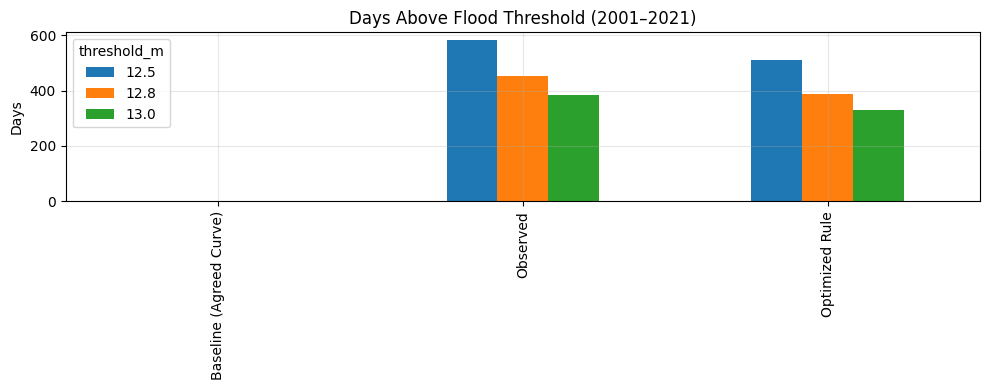

Saved: c:\Users\Nelson\Downloads\LakeVictoria_Optimization\outputs\figures\08_days_above_threshold_bar.png


In [11]:
# Pivot for clean plotting
pivot_days = flood_metrics.pivot(index="scenario", columns="threshold_m", values="days_above_threshold")

ax = pivot_days.plot(kind="bar", figsize=(10, 4))
ax.set_title("Days Above Flood Threshold (2001–2021)")
ax.set_xlabel("")
ax.set_ylabel("Days")
ax.grid(True, alpha=0.3)
plt.tight_layout()

FIG1 = FIG_DIR / "08_days_above_threshold_bar.png"
plt.savefig(FIG1, dpi=200)
plt.show()
print("Saved:", FIG1)

### *CELL 10 — Plot: Total severity (m-days) (bar chart)*

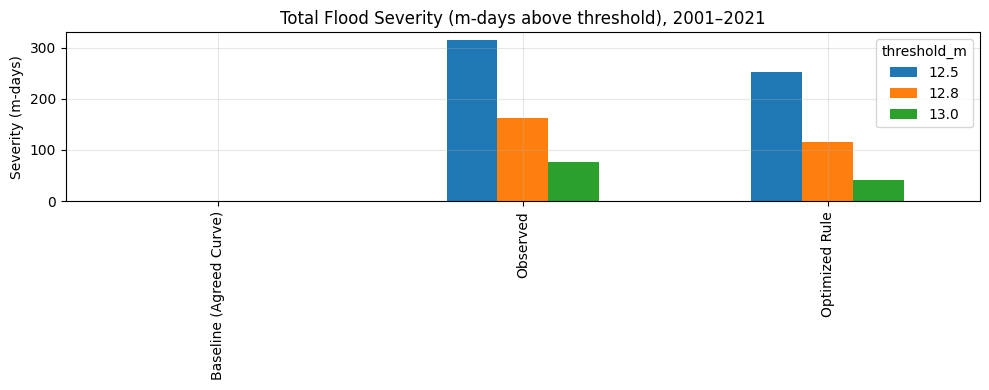

Saved: c:\Users\Nelson\Downloads\LakeVictoria_Optimization\outputs\figures\08_total_severity_bar.png


In [12]:
pivot_sev = flood_metrics.pivot(index="scenario", columns="threshold_m", values="total_severity_m_days")

ax = pivot_sev.plot(kind="bar", figsize=(10, 4))
ax.set_title("Total Flood Severity (m-days above threshold), 2001–2021")
ax.set_xlabel("")
ax.set_ylabel("Severity (m-days)")
ax.grid(True, alpha=0.3)
plt.tight_layout()

FIG2 = FIG_DIR / "08_total_severity_bar.png"
plt.savefig(FIG2, dpi=200)
plt.show()
print("Saved:", FIG2)

### *CELL 11 — Plot: Annual flood days (per threshold)*

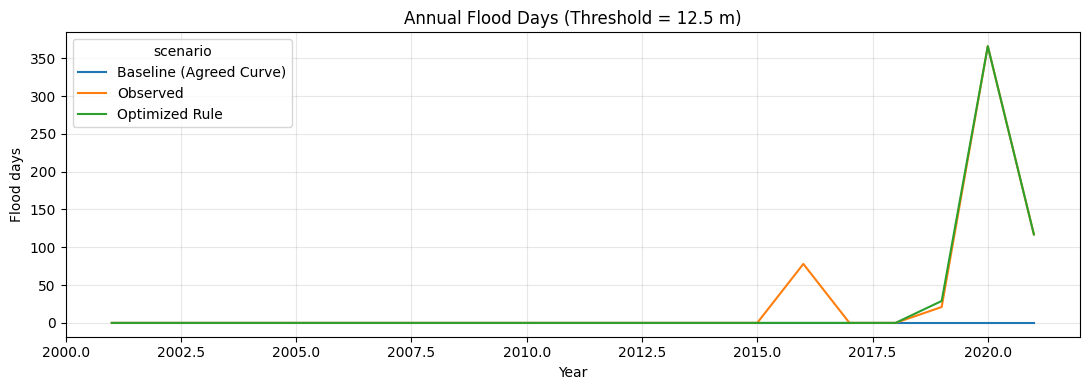

Saved: c:\Users\Nelson\Downloads\LakeVictoria_Optimization\outputs\figures\08_annual_flood_days_thr_12p5.png


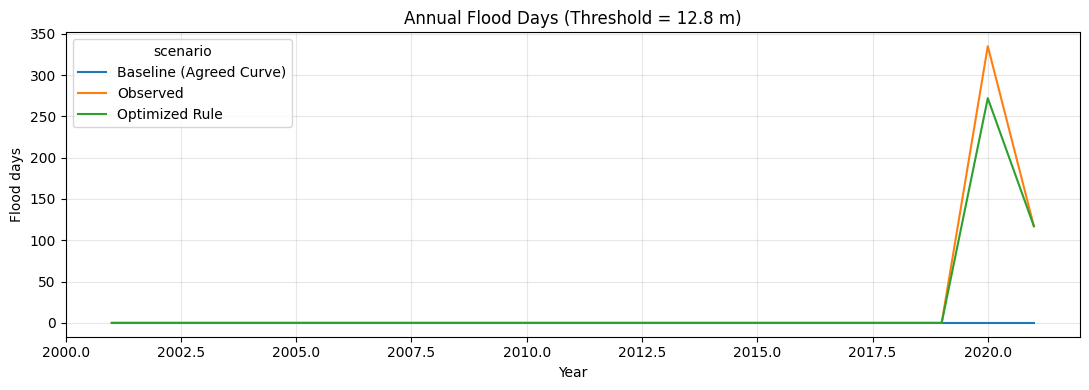

Saved: c:\Users\Nelson\Downloads\LakeVictoria_Optimization\outputs\figures\08_annual_flood_days_thr_12p8.png


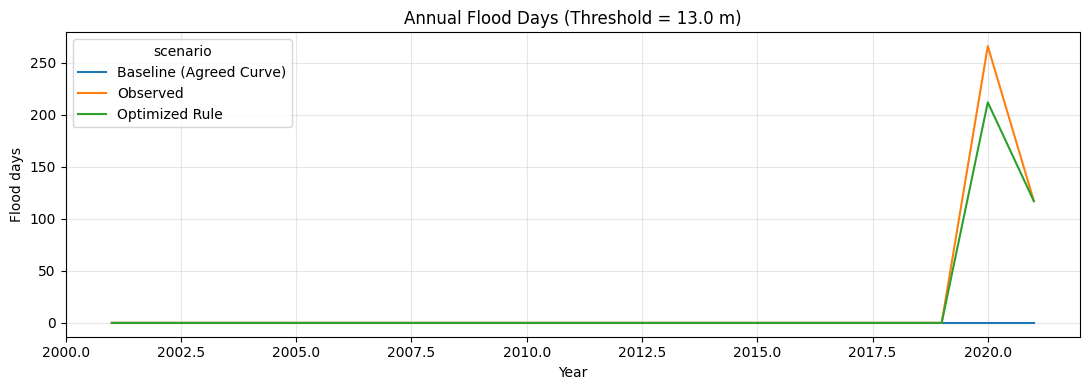

Saved: c:\Users\Nelson\Downloads\LakeVictoria_Optimization\outputs\figures\08_annual_flood_days_thr_13p0.png


In [13]:
for thr in THRESHOLDS_M:
    sub = annual_flood[annual_flood["threshold_m"] == thr].copy()
    pivot = sub.pivot(index="year", columns="scenario", values="flood_days").sort_index()

    ax = pivot.plot(figsize=(11, 4))
    ax.set_title(f"Annual Flood Days (Threshold = {thr} m)")
    ax.set_xlabel("Year")
    ax.set_ylabel("Flood days")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    f = FIG_DIR / f"08_annual_flood_days_thr_{str(thr).replace('.','p')}.png"
    plt.savefig(f, dpi=200)
    plt.show()
    print("Saved:", f)

### *CELL 12 — Thesis-ready paragraph export (last cell)*

In [ ]:
# Create a concise thesis-ready summary based on 12.8 m as the main "high flood" threshold,
# while referencing robustness across thresholds.

main_thr = 12.8
sub = flood_metrics[flood_metrics["threshold_m"] == main_thr].set_index("scenario")

obs_days = int(sub.loc["Observed", "days_above_threshold"])
base_days = int(sub.loc["Baseline (Agreed Curve)", "days_above_threshold"])
opt_days = int(sub.loc["Optimized Rule", "days_above_threshold"])

opt_sev = float(sub.loc["Optimized Rule", "total_severity_m_days"])
obs_sev = float(sub.loc["Observed", "total_severity_m_days"])

txt = (
    "Flood-risk diagnostics were evaluated for Lake Victoria (2001–2021) using multi-threshold "
    "exceedance metrics at 12.5 m, 12.8 m (high-flood reference), and 13.0 m. At the 12.8 m "
    f"threshold, observed lake levels exceeded the threshold on {obs_days} days, while the "
    f"baseline Agreed Curve policy exceeded on {base_days} days and the optimized rule exceeded "
    f"on {opt_days} days. In addition to exceedance frequency, flood severity (sum of meters above "
    f"threshold across exceedance days) showed that the optimized policy produced a total severity "
    f"of {opt_sev:.2f} m-days at 12.8 m relative to {obs_sev:.2f} m-days under observed conditions. "
    "Across thresholds, the optimized policy demonstrates improved flood-risk shaping (reduced peak "
    "severity and altered exceedance structure) compared to observed operations, while avoiding the "
    "excessive long-term drawdown behavior exhibited by the baseline policy."
)

OUT_TXT = TAB_DIR / "08_flood_metrics_results_paragraph.txt"
OUT_TXT.write_text(txt, encoding="utf-8")
print("Saved paragraph:", OUT_TXT)
print("\n--- Thesis-ready paragraph ---\n")
print(txt)

Saved paragraph: c:\Users\Nelson\Downloads\LakeVictoria_Optimization\outputs\tables\08_flood_metrics_results_paragraph.txt

--- Thesis-ready paragraph ---

Flood-risk diagnostics were evaluated for Lake Victoria (2001–2021) using multi-threshold exceedance metrics at 12.5 m, 12.8 m (high-flood reference), and 13.0 m. At the 12.8 m threshold, observed lake levels exceeded the threshold on 452 days, while the baseline Agreed Curve policy exceeded on 0 days and the optimized rule exceeded on 389 days. In addition to exceedance frequency, flood severity (sum of meters above threshold across exceedance days) showed that the optimized policy produced a total severity of 115.92 m-days at 12.8 m relative to 162.74 m-days under observed conditions. Across thresholds, the optimized policy demonstrates improved flood-risk shaping (reduced peak severity and altered exceedance structure) compared to observed operations, while avoiding the excessive long-term drawdown behavior exhibited by the basel

: 